In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import warnings

warnings.filterwarnings('ignore')

# Load final dataset
df = pd.read_csv('df_final.csv')

print(f"done")
print(f"  Shape   : {df.shape}")
print(f"  Columns : {df.columns.tolist()}")

done
  Shape   : (711168, 15)
  Columns : ['storeId', 'rating', 'sold', 'price', 'shippingCost', 'category_name', 'category_id', 'type', 'effective_price', 'discount_aggressiveness', 'value_score', 'price_vs_category_avg', 'sales_per_discount', 'price_rank_in_category', 'store_avg_sold']


# Prepare Features for Clustering

clustering : an unsupervised machine learning technique that automatically
groups similar data points into clusters . only works on numeric features.

In [3]:
clustering_features = [
    'sales_per_discount',
    'discount_aggressiveness',
    'value_score',
    'store_avg_sold',
    'rating',
    'effective_price',
    'price',
    'price_vs_category_avg',
    'price_rank_in_category',
    'shippingCost'
]
X = df[clustering_features].copy()
# Fill any remaining NaN
X = X.fillna(X.median())
# Scale features — clustering is distance-based
# so all features must be on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f" Features prepared ")
print(f"  Shape : {X_scaled.shape}")

 Features prepared 
  Shape : (711168, 10)


 # Elbow Method 

We plot inertia for each K and look for the "elbow" = the point where adding more clusters stops giving meaningful improvement.IT is Like bending your arm: after the elbow, the curve flattens out.That K is our sweet spot.


  K=2 → inertia: 5201899
  K=3 → inertia: 4144719
  K=4 → inertia: 3583965
  K=5 → inertia: 3165935
  K=6 → inertia: 2797570
  K=7 → inertia: 2531925
  K=8 → inertia: 2347898
  K=9 → inertia: 2183654
  K=10 → inertia: 2049659


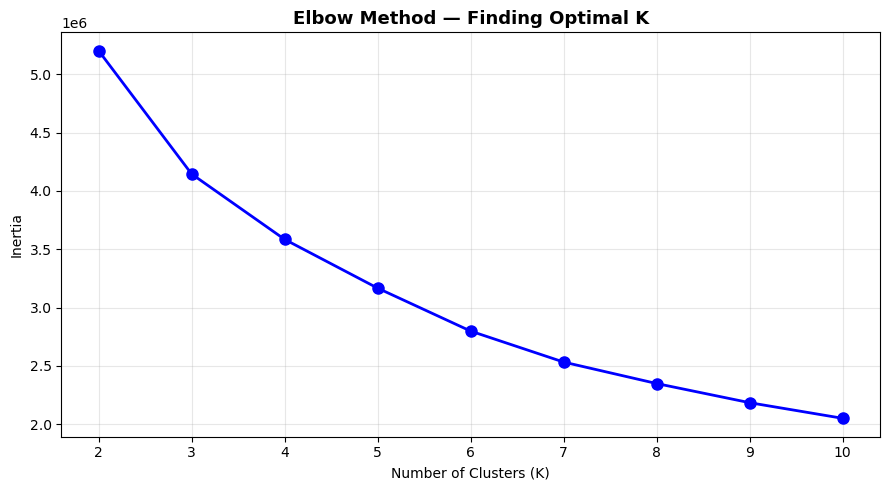

In [4]:
inertias = []
k_range  = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k} → inertia: {km.inertia_:.0f}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Finding Optimal K', fontsize=13, fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

so i cannot see a visible sharp elbow (the curve is smooth ) but but the drp from k2 to k3 is huge (1.057.180) but before deciding we will see Silhouette scores.

# Silhouette score :

  K=2 → silhouette score: 0.2843
  K=3 → silhouette score: 0.3096
  K=4 → silhouette score: 0.2667
  K=5 → silhouette score: 0.2472
  K=6 → silhouette score: 0.2485
  K=7 → silhouette score: 0.2472
  K=8 → silhouette score: 0.2573
  K=9 → silhouette score: 0.2592
  K=10 → silhouette score: 0.2466


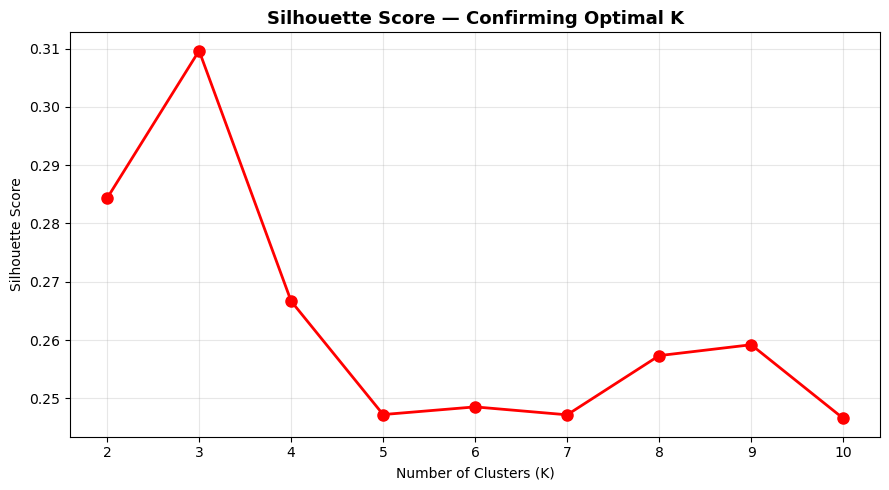


  Best K based on Silhouette Score : 3


In [5]:
# Silhouette score measures how well each point fits its cluster
# Score ranges from -1 to 1:
#  Close to 1  = point fits perfectly in its cluster
#  Close to 0  = point is between two clusters
#  Negative    = point is in the wrong cluster
# Best K = highest silhouette score

silhouette_scores = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score  = silhouette_score(X_scaled, labels, sample_size=50000, random_state=42)
    silhouette_scores.append(score)
    print(f"  K={k} → silhouette score: {score:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Confirming Optimal K', fontsize=13, fontweight='bold')
plt.xticks(k_range) # show every K value on x axis.
plt.grid(True, alpha=0.3) # faint grid =easier to trace values
plt.tight_layout()
plt.show()

best_k = k_range[np.argmax(silhouette_scores)]
print(f"\n  Best K based on Silhouette Score : {best_k}")

so we choose k= 3 

# Run K-Means 

In [6]:
# n_init=10 → runs 10 times with different seeds, picks best result
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

print(f" K-Means clustering done")
print(f"\nCluster distribution:")
print(df['cluster_kmeans'].value_counts().sort_index())

 K-Means clustering done

Cluster distribution:
cluster_kmeans
0     58048
1    261124
2    391996
Name: count, dtype: int64


 # Run DBSCAN

In [7]:
# DBSCAN finds clusters based on density — no need to specify K
# It also automatically detects outliers (label = -1)
# eps    = max distance between two points to be considered neighbors
# min_samples = min points to form a dense region (cluster)
# We use a sample for speed (DBSCAN is slow on 700k rows)

sample_size = 60000
X_sample = X_scaled[:sample_size]

dbscan = DBSCAN(eps=0.5, min_samples=50)
dbscan_labels = dbscan.fit_predict(X_sample)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_outliers  = (dbscan_labels == -1).sum()

print(f" DBSCAN clustering done")
print(f"  Clusters found : {n_clusters}")
print(f"  Outliers found : {n_outliers} ({n_outliers/sample_size*100:.1f}%)")
print(f"\nCluster distribution:")
print(pd.Series(dbscan_labels).value_counts().sort_index())

 DBSCAN clustering done
  Clusters found : 11
  Outliers found : 29631 (49.4%)

Cluster distribution:
-1     29631
 0       118
 1      8289
 2      7987
 3     12388
 4       219
 5       509
 6        78
 7       418
 8       139
 9       165
 10       59
Name: count, dtype: int64


**interpretation**: almost half of the data is "noise" >> eps = 0.5 maybe it is too small for my data >> so lets **try it with different eps** 

In [8]:
for eps in [0.8, 1.0, 1.5, 2.0]:
    db = DBSCAN(eps=eps, min_samples=50)
    labels = db.fit_predict(X_sample)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = (labels == -1).sum()
    print(f"eps={eps} → clusters: {n_clusters} | outliers: {n_outliers} ({n_outliers/len(X_sample)*100:.1f}%)")

eps=0.8 → clusters: 5 | outliers: 9602 (16.0%)
eps=1.0 → clusters: 3 | outliers: 5184 (8.6%)
eps=1.5 → clusters: 2 | outliers: 1586 (2.6%)
eps=2.0 → clusters: 3 | outliers: 373 (0.6%)


**interpretation** :this confirms that DBSCAN is useless 

# lets see cluster profiles 

In [8]:
cluster_profiles = df.groupby('cluster_kmeans')[clustering_features + ['sold']].mean().round(3)
print("Cluster Profiles_mean:")
print(cluster_profiles.to_string())

Cluster Profiles_mean:
                sales_per_discount  discount_aggressiveness  value_score  store_avg_sold  rating  effective_price     price  price_vs_category_avg  price_rank_in_category  shippingCost     sold
cluster_kmeans                                                                                                                                                                                   
0                            0.274                    1.699        0.054           1.433   1.322            6.522  1251.919                  3.939                   0.862       207.013    7.270
1                            1.191                    6.635        2.696           3.895   4.768            2.711    46.053                  0.531                   0.418        13.545  131.780
2                            0.147                    1.813        0.046           1.791   0.704            3.455    94.458                  0.722                   0.501        22.453    2.117


# interpretation :
| Metric | Cluster 0  | Cluster 1  | Cluster 2  |
|---|---|---|---|
| `sold` | 7.27 | **131.78** | 2.12 |
| `rating` | 1.32 | **4.77** | 0.70 |
| `price` | **1251.92 ** | 46.05  | 94.46  |
| `discount_aggressiveness` | 1.70 | **6.64** | 1.81 |
| `sales_per_discount` | 0.27 | **1.19** | 0.15 |
| `value_score` | 0.05 | **2.70** | 0.05 |
| `shippingCost` | **207.01 ** | 13.55  | 22.45  |
###  Strategy Names : 

| Cluster | Name | Summary |
|---|---|---|
| Cluster 0 |  **overpriced low performer** | Very expensive, high shipping, low sales, bad rating |
| Cluster 1 |  **Smart Discounter** | Affordable, high discount efficiency, best sales, excellent rating |
| Cluster 2 |  **Underperformer** | Medium price, barely discounts, terrible sales, worst rating |


In [9]:
# Analyze each cluster's average feature values
# to understand what pricing strategy it represents

cluster_profiles = df.groupby('cluster_kmeans')[clustering_features + ['sold']].mean().round(2)
print("Cluster Profiles (mean values per cluster):")
print(cluster_profiles.to_string())

strategy_names = {
    0: 'overpriced low performer',  
    1: 'Smart Discounter',          
    2: 'underperformer',     
}

df['strategy'] = df['cluster_kmeans'].map(strategy_names)

print("\n Strategy labels assigned:")
print(df['strategy'].value_counts())

Cluster Profiles (mean values per cluster):
                sales_per_discount  discount_aggressiveness  value_score  store_avg_sold  rating  effective_price    price  price_vs_category_avg  price_rank_in_category  shippingCost    sold
cluster_kmeans                                                                                                                                                                                 
0                             0.27                     1.70         0.05            1.43    1.32             6.52  1251.92                   3.94                    0.86        207.01    7.27
1                             1.19                     6.63         2.70            3.89    4.77             2.71    46.05                   0.53                    0.42         13.55  131.78
2                             0.15                     1.81         0.05            1.79    0.70             3.46    94.46                   0.72                    0.50         22.45    2

# BEST STRATEGY PER CATEGORY

Best Performing Strategy per Category:
 category_id                      category_name    best_strategy   avg_sold
           5     electrical-equipments-supplies Smart Discounter  90.665493
           6                    home-appliances Smart Discounter 191.727931
           7                    computer-office Smart Discounter 223.607724
          13                   home-improvement Smart Discounter  83.558659
          15                        home-garden Smart Discounter 113.672070
          18               sports-entertainment Smart Discounter  99.333333
          21          education-office-supplies Smart Discounter 120.606870
          26                       toys-hobbies Smart Discounter 163.505061
          30                security-protection Smart Discounter 122.662439
          34            automobiles-motorcycles Smart Discounter  90.817013
          39                    lights-lighting Smart Discounter 213.155590
          42                           hardware S

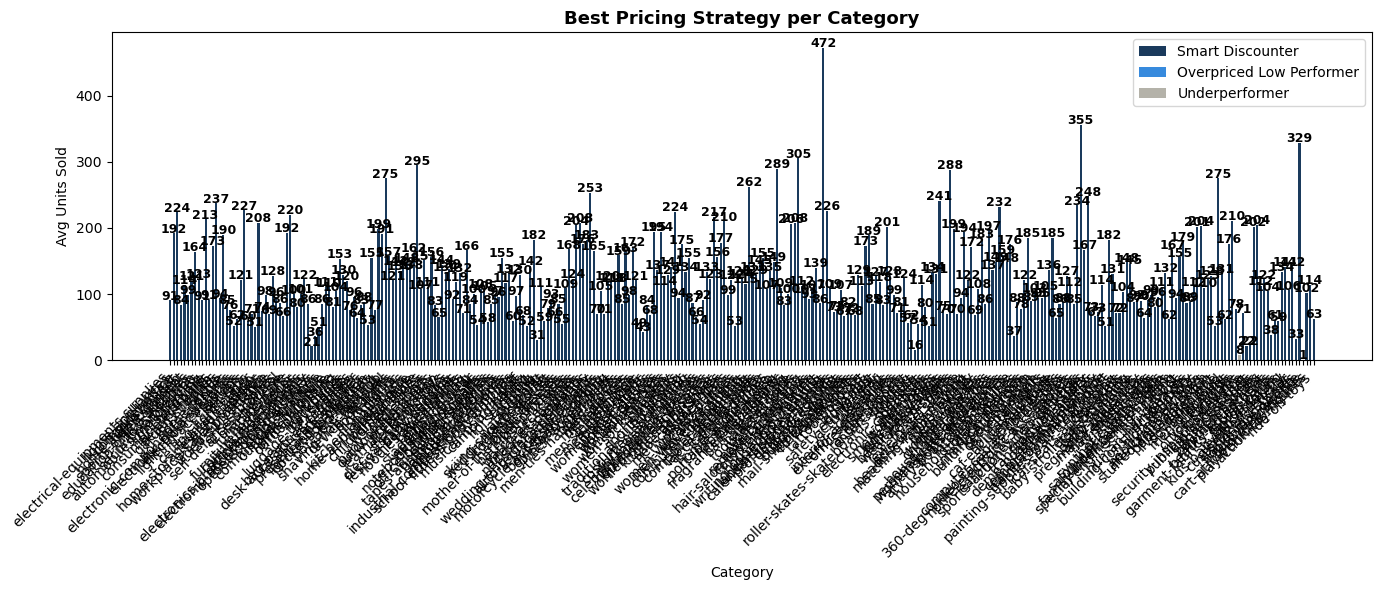

In [10]:
# For each category = which strategy has the highest average sold?
# This becomes the TARGET LABEL for our classification notebook
from matplotlib.patches import Patch
strategy_names = {
    0: 'Overpriced Low Performer',
    1: 'Smart Discounter',
    2: 'Underperformer'
}

df['strategy'] = df['cluster_kmeans'].map(strategy_names)

# Group by category + strategy → get avg sold per group
category_strategy = (
    df.groupby(['category_id', 'category_name', 'strategy'])['sold']
    .mean()
    .reset_index()
    .rename(columns={'sold': 'avg_sold'})
)

# For each category → keep only the strategy with highest avg sold
best_strategy_per_category = (
    category_strategy
    .sort_values(['category_id', 'avg_sold'], ascending=[True, False])
    .groupby('category_id')
    .first()
    .reset_index()
    .rename(columns={'strategy': 'best_strategy'})
)

print("Best Performing Strategy per Category:")
print("=" * 60)
print(best_strategy_per_category[['category_id', 'category_name',
                                   'best_strategy', 'avg_sold']].to_string(index=False))

#  Visualize

plt.figure(figsize=(14, 6))

colors_map = {
    'Smart Discounter'        : '#1A3A5C',
    'Overpriced Low Performer': '#378ADD',
    'Underperformer'          : '#B4B2A9'
}

bar_colors = [colors_map.get(s, '#B4B2A9')
              for s in best_strategy_per_category['best_strategy']]

bars = plt.bar(
    best_strategy_per_category['category_name'],
    best_strategy_per_category['avg_sold'],
    color=bar_colors,
    edgecolor='none',
    width=0.6
)

# Value labels on top
for bar, val in zip(bars, best_strategy_per_category['avg_sold']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.0f}',
             ha='center', fontsize=9, fontweight='bold')

# Legend

legend_elements = [
    Patch(facecolor='#1A3A5C', label='Smart Discounter'),
    Patch(facecolor='#378ADD', label='Overpriced Low Performer'),
    Patch(facecolor='#B4B2A9', label='Underperformer')
]
plt.legend(handles=legend_elements, fontsize=10)

plt.title('Best Pricing Strategy per Category',
          fontsize=13, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Avg Units Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**interpretation**
Smart Discounter : 296 out of 298 categories (99.3%)
    Underperformer   : 2 categories only
   >office-software        
   >cart-atilde-o-presente 

In [11]:
# Your classification model has a challenge:
# 99.3% of categories → same label (Smart Discounter)
# This is a CLASS IMBALANCE problem

print(df['strategy'].value_counts())
print(df['strategy'].value_counts(normalize=True) * 100)

strategy
Underperformer              391996
Smart Discounter            261124
Overpriced Low Performer     58048
Name: count, dtype: int64
strategy
Underperformer              55.120028
Smart Discounter            36.717625
Overpriced Low Performer     8.162347
Name: proportion, dtype: float64


In [12]:
import joblib

df.to_csv('df_clustered.csv', index=False)
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f" Saved df_clustered.csv")
print(f" Saved kmeans_model.pkl")
print(f" Saved scaler.pkl")

 Saved df_clustered.csv
 Saved kmeans_model.pkl
 Saved scaler.pkl


# . pkl : 

Normally when your Python script stops running, everything in memory (your trained model, your scaler, your encoder) disappears. Pickle "freezes" a Python object exactly as it is and saves it to disk as a binary file — so you can "unfreeze" it later in a completely different script and it works identically.